# C3 — Phase 2B: Explainable AI (XAI) Layer
**Project:** R26-DS-012 | **Student:** Seneviratne K.A.U.A. | IT22093950

Builds a three-layer XAI stack on top of the Phase 2A risk model:
- **SHAP** (global + local, TreeExplainer)
- **LIME** cross-validator (top-3 Jaccard agreement with SHAP)
- **DiCE** counterfactuals (High → what changes to become Medium?)
- **Natural Language** bridge for clinician dashboard and user app

**Requires from Phase 2A:** Upload the Phase 2A zip when prompted.

**Requires from Phase 1:** Upload combined_c3_test.csv and combined_c3_balanced.csv when prompted.

---
| Cell | Content |
|---|---|
| 1 | Install packages |
| 2 | Imports, config, load artifacts + test data |
| 3 | SHAP global + local explanations |
| 4 | LIME cross-validator |
| 5 | SHAP vs LIME consistency (Jaccard) |
| 6 | DiCE counterfactual explanations |
| 7 | Natural language explainer |
| 8 | Clinician XAI payload builder |
| 9 | Dissertation figures |
| 10 | Summary + download |

In [1]:
# =========================
# Cell 1: Environment check
# =========================
import importlib
from importlib.metadata import version, PackageNotFoundError

required = {
    "shap": "shap",
    "lime": "lime",
    "dice_ml": "dice-ml",
    "xgboost": "xgboost",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib"
}

missing = []
loaded_modules = {}

for mod_name, pkg_name in required.items():
    try:
        loaded_modules[mod_name] = importlib.import_module(mod_name)
    except Exception:
        missing.append(pkg_name)

if missing:
    print("Missing packages:", ", ".join(missing))
    print("Install them with:")
    print(f"!pip -q install {' '.join(missing)}")
else:
    print("All packages ready.")

    def safe_version(module_obj, package_name):
        # Try module.__version__ first
        ver = getattr(module_obj, "__version__", None)
        if ver:
            return ver

        # Fallback to package metadata
        try:
            return version(package_name)
        except PackageNotFoundError:
            return "installed (version unavailable)"
        except Exception:
            return "installed (version unavailable)"

    shap = loaded_modules["shap"]
    lime = loaded_modules["lime"]
    dice_ml = loaded_modules["dice_ml"]
    xgb = loaded_modules["xgboost"]
    sklearn = loaded_modules["sklearn"]

    print(f"  shap    : {safe_version(shap, 'shap')}")
    print(f"  lime    : {safe_version(lime, 'lime')}")
    print(f"  dice_ml : {safe_version(dice_ml, 'dice-ml')}")
    print(f"  xgboost : {safe_version(xgb, 'xgboost')}")
    print(f"  sklearn : {safe_version(sklearn, 'scikit-learn')}")

Missing packages: lime, dice-ml
Install them with:
!pip -q install lime dice-ml


In [2]:
!pip -q install lime dice-ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.0 MB/s eta 0:00:00


In [3]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [5]:
# ================================================================
# CELL 2 — Imports, Config & Load Artifacts
# ================================================================
# FIX v2: Correct model priority (XGBoost pkl first, CatBoost cbm second).
#         Load test data from combined_c3_test.csv (Phase 1) instead of
#         re-splitting nhanes raw — avoids distribution mismatch.
#         CLINICAL_RISK_FEATS defined here (needed in Cells 3, 8, 9).
#         train_test_split syntax bug fixed.
# ================================================================
import warnings, json, zipfile, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

import shap
shap.initjs()
from lime import lime_tabular
import dice_ml
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

SEED = 42
np.random.seed(SEED)

ARTIFACT_DIR = Path('c3_xai_artifacts')
FIGURE_DIR   = Path('c3_xai_figures')
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

RISK_LABELS     = {0: 'Low', 1: 'Medium', 2: 'High'}
PALETTE         = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
# Features that come directly from C1 / C2 / C4 clinical signals
CLINICAL_RISK_FEATS = {'physiological_risk', 'behavioral_risk',
                        'textual_risk', 'composite_risk'}
plt.style.use('seaborn-v0_8-whitegrid')

# ── Upload and unpack Phase 2A zip ──────────────────────────
from google.colab import files
print('═'*60)
print('UPLOAD 1 of 2: C3_Phase2_Artifacts.zip from Phase 2A')
print('═'*60)
uploaded = files.upload()

zip_file = next((k for k in uploaded if k.endswith('.zip')), None)
if not zip_file:
    raise FileNotFoundError('No .zip found. Upload the Phase 2A artifacts zip.')

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall('phase2_artifacts')
print(f'Extracted: {zip_file}')
P2 = Path('phase2_artifacts')

# ── Load feature schema ─────────────────────────────────────
schema_path = next(P2.rglob('feature_cols.json'), None) or \
              next(P2.rglob('feature_schema_phase2.json'), None)
if not schema_path:
    raise FileNotFoundError('feature_cols.json not found in zip.')

with open(schema_path) as f:
    schema = json.load(f)

FEATURE_COLS    = schema.get('feature_cols', schema.get('features', []))
RISK_LABELS_STR = {int(k): v for k, v in schema.get('risk_labels',
                   {'0':'Low','1':'Medium','2':'High'}).items()}
CAT_INDICES     = schema.get('cat_feature_indices', [1, 2])
USE_F9          = schema.get('use_f9', True)

# FIX: correct feature list if schema is the phase2 variant
if not FEATURE_COLS:
    FEATURE_COLS = [
        'age_norm','gender_enc','marital_enc','education_enc','income_enc',
        'physiological_risk','behavioral_risk','textual_risk','composite_risk',
        'risk_tier_enc','interaction_count_norm','last_reward_norm','escalation_count_norm'
    ]
ACTIVE_COLS = FEATURE_COLS
print(f'Feature columns ({len(ACTIVE_COLS)}): {ACTIVE_COLS}')

# ── Load risk model (XGBoost pkl preferred; CatBoost cbm fallback) ──
# FIX: Phase 2A selected XGBoost_SMOTENC — check pkl first
xgb_pkl  = next(P2.rglob('xgboost*.pkl'), None)
risk_pkl  = next(P2.rglob('risk_model_*.pkl'), None)
any_pkl   = xgb_pkl or risk_pkl
cbm_path  = next(P2.rglob('*.cbm'), None)
shap_pkl  = next(P2.rglob('shap_explainer.pkl'), None)

IS_CATBOOST = False
risk_model  = None

if any_pkl:
    payload    = joblib.load(any_pkl)
    risk_model = payload['model'] if isinstance(payload, dict) else payload
    print(f'Loaded sklearn/XGBoost model from: {any_pkl.name}')
elif cbm_path:
    risk_model  = CatBoostClassifier()
    risk_model.load_model(str(cbm_path))
    IS_CATBOOST = True
    print(f'Loaded CatBoost model: {cbm_path.name}')
elif shap_pkl:
    # Recover model from saved SHAP explainer (Phase 2A saves it inside)
    shap_bundle = joblib.load(shap_pkl)
    risk_model  = shap_bundle.get('model', None) if isinstance(shap_bundle, dict) else None
    if risk_model is not None:
        print('Recovered risk model from shap_explainer.pkl')
    else:
        print('WARNING: No risk model pkl found. Will use SHAP explainer directly.')
else:
    raise FileNotFoundError(
        'No risk model found in zip.\n'
        'Before downloading the Phase 2A zip, run in Phase 2A:\n'
        '  import joblib\n'
        '  joblib.dump({"model": final_model}, "/content/c3_phase2_artifacts/xgboost_smotenc.pkl")'
    )

# ── Upload combined_c3_test.csv (Phase 1 output) ────────────
print('\n' + '═'*60)
print('UPLOAD 2 of 2: combined_c3_test.csv  (from Phase 1 outputs)')
print('═'*60)
uploaded2 = files.upload()
test_csv  = next((k for k in uploaded2 if 'test' in k.lower() and k.endswith('.csv')), None)
if not test_csv:
    raise FileNotFoundError('Upload combined_c3_test.csv from Phase 1.')

df_test = pd.read_csv(test_csv)
print(f'Test set loaded: {df_test.shape}')
print(f'Columns: {list(df_test.columns)}')

# Leakage fix: zero risk_tier_enc (same as Phase 2A)
if 'risk_tier_enc' in df_test.columns:
    df_test['risk_tier_enc'] = 0

# Ensure all feature columns exist
rng = np.random.default_rng(SEED)
for col in ACTIVE_COLS:
    if col not in df_test.columns:
        print(f'  Synthesising missing column: {col}')
        df_test[col] = 0.0

X_test  = df_test[ACTIVE_COLS].values.astype(np.float32)
y_test  = df_test['risk_tier'].values.astype(np.int64)

# Also load the balanced training set for background distributions
# (LIME and DiCE need training data for surrogate fitting)
print('\nUpload combined_c3_balanced.csv (Phase 1 train set for LIME/DiCE background)...')
uploaded3 = files.upload()
train_csv = next((k for k in uploaded3 if 'balanced' in k.lower() and k.endswith('.csv')), None)
if train_csv:
    df_train = pd.read_csv(train_csv)
    if 'risk_tier_enc' in df_train.columns:
        df_train['risk_tier_enc'] = 0
    for col in ACTIVE_COLS:
        if col not in df_train.columns:
            df_train[col] = 0.0
    X_train_bg = df_train[ACTIVE_COLS].values.astype(np.float32)
    y_train_bg = df_train['risk_tier'].values.astype(np.int64)
    # X_full / y_full: combined for DiCE context
    X_full = np.vstack([X_train_bg, X_test])
    y_full = np.concatenate([y_train_bg, y_test])
    print(f'Train background loaded: {X_train_bg.shape}')
else:
    print('No balanced CSV uploaded — using test set as background (less ideal).')
    X_train_bg = X_test.copy()
    y_train_bg = y_test.copy()
    X_full     = X_test.copy()
    y_full     = y_test.copy()

# ── predict_proba wrapper ────────────────────────────────────
def predict_proba(X):
    """Unified predict_proba for XGBoost or CatBoost."""
    X = np.asarray(X, dtype=np.float32)
    if IS_CATBOOST:
        return risk_model.predict_proba(Pool(X, cat_features=CAT_INDICES))
    return risk_model.predict_proba(X)

# Quick sanity check
sample_probs = predict_proba(X_test[:3])
print(f'\nSanity check — predict_proba shape: {sample_probs.shape}')
print(f'Test class dist: {dict(zip(*np.unique(y_test, return_counts=True)))}')
print('\nCell 2 complete ✓')

════════════════════════════════════════════════════════════
UPLOAD 1 of 2: C3_Phase2_Artifacts.zip from Phase 2A
════════════════════════════════════════════════════════════


Saving C3_Phase2_Artifacts (1).zip to C3_Phase2_Artifacts (1) (1).zip
Extracted: C3_Phase2_Artifacts (1) (1).zip
Feature columns (13): ['age_norm', 'gender_enc', 'marital_enc', 'education_enc', 'income_enc', 'physiological_risk', 'behavioral_risk', 'textual_risk', 'composite_risk', 'risk_tier_enc', 'interaction_count_norm', 'last_reward_norm', 'escalation_count_norm']
Loaded sklearn/XGBoost model from: xgboost_smotenc.pkl

════════════════════════════════════════════════════════════
UPLOAD 2 of 2: combined_c3_test.csv  (from Phase 1 outputs)
════════════════════════════════════════════════════════════


Saving combined_c3_test.csv to combined_c3_test.csv
Test set loaded: (1073, 15)
Columns: ['age_norm', 'gender_enc', 'marital_enc', 'education_enc', 'income_enc', 'physiological_risk', 'behavioral_risk', 'textual_risk', 'composite_risk', 'risk_tier_enc', 'interaction_count_norm', 'last_reward_norm', 'escalation_count_norm', 'risk_tier', 'source']

Upload combined_c3_balanced.csv (Phase 1 train set for LIME/DiCE background)...


Saving combined_c3_balanced.csv to combined_c3_balanced (1).csv
Train background loaded: (7893, 13)

Sanity check — predict_proba shape: (3, 3)
Test class dist: {np.int64(0): np.int64(658), np.int64(1): np.int64(239), np.int64(2): np.int64(176)}

Cell 2 complete ✓


In [6]:
# ================================================================
# CELL 3 — SHAP: Global + Local Explanations
# ================================================================
# Global: which features drive risk across the population
# Local:  which features drove THIS specific patient's prediction
#
# Citation: Lundberg & Lee 2017 NeurIPS
# TreeExplainer works for both XGBoost and CatBoost.
# FIX v2: Handle 3-D shap_values array (n_samples, n_features, n_classes)
#         that XGBoost TreeExplainer returns.
# ================================================================

N_SHAP = min(500, len(X_test))   # SHAP on first 500 test rows for speed
X_shap = X_test[:N_SHAP]
y_shap = y_test[:N_SHAP]

print(f'Building SHAP TreeExplainer on {N_SHAP} test samples...')

if IS_CATBOOST:
    explainer_shap = shap.TreeExplainer(risk_model)
    raw_shap = explainer_shap.shap_values(X_shap)   # list of 3 arrays
else:
    explainer_shap = shap.TreeExplainer(risk_model)
    raw_shap = explainer_shap.shap_values(X_shap)
    # XGBoost multiclass: can be list[n_classes] of (n,f) OR (n,f,c) array

# ── Normalise SHAP output to a list of (N, F) arrays, one per class ──
if isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 3:
    # (n_samples, n_features, n_classes) → list of (n,f)
    shap_values = [raw_shap[:, :, c] for c in range(raw_shap.shape[2])]
elif isinstance(raw_shap, np.ndarray) and raw_shap.ndim == 2:
    # Binary fallback
    shap_values = [raw_shap]
else:
    # Already a list
    shap_values = raw_shap

N_CLASSES = len(shap_values)
print(f'SHAP computed for {N_CLASSES} output class(es).')

# ── Global importance: mean |SHAP| averaged across all classes ──
mean_abs_shap   = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
shap_high       = shap_values[2] if N_CLASSES >= 3 else shap_values[-1]  # High-risk class

shap_global_df = pd.DataFrame({
    'feature':       ACTIVE_COLS,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('\nTop global SHAP features:')
print(shap_global_df.to_string(index=False))

# ── Local explanations: one sample per class ──
local_explanations = []

for cls_label in [0, 1, 2]:
    idxs = np.where(y_shap == cls_label)[0]
    if len(idxs) == 0:
        continue
    pi     = idxs[0]
    probs  = predict_proba(X_shap[pi:pi+1])[0]
    pred   = int(np.argmax(probs))         # FIX: defined per-patient
    # Use SHAP for the *predicted* class (most clinically relevant)
    sv     = shap_values[pred][pi]

    feat_contrib = sorted(
        zip(ACTIVE_COLS, sv, X_shap[pi]),
        key=lambda x: abs(x[1]), reverse=True
    )
    local_explanations.append({
        'patient_idx':   int(pi),
        'true_label':    RISK_LABELS_STR[cls_label],
        'predicted':     RISK_LABELS_STR[pred],
        'probabilities': {RISK_LABELS_STR[i]: float(p) for i, p in enumerate(probs)},
        'top_drivers': [
            {
                'feature':          f,
                'shap_value':       float(s),
                'feature_value':    float(v),
                'is_clinical_risk': f in CLINICAL_RISK_FEATS
            }
            for f, s, v in feat_contrib[:5]
        ]
    })
    print(f'\nPatient (true={RISK_LABELS_STR[cls_label]}, pred={RISK_LABELS_STR[pred]}):')
    for f, s, v in feat_contrib[:5]:
        direction = '▲' if s > 0 else '▼'
        print(f'  {direction} {f:<30} SHAP={s:+.4f}  value={v:.3f}')

# Save SHAP artifacts
joblib.dump({
    'explainer':          explainer_shap,
    'shap_values':        shap_values,
    'shap_global_df':     shap_global_df,
    'local_explanations': local_explanations,
    'feature_cols':       ACTIVE_COLS,
}, ARTIFACT_DIR / 'xai_shap_explainer.pkl')
print('\nSaved: xai_shap_explainer.pkl ✓')
print('Cell 3 complete ✓')

Building SHAP TreeExplainer on 500 test samples...
SHAP computed for 3 output class(es).

Top global SHAP features:
               feature  mean_abs_shap
    physiological_risk       2.831668
        composite_risk       1.085129
       behavioral_risk       0.287382
              age_norm       0.149739
          textual_risk       0.078730
            gender_enc       0.072216
            income_enc       0.064469
      last_reward_norm       0.034797
         education_enc       0.000815
           marital_enc       0.000234
         risk_tier_enc       0.000000
interaction_count_norm       0.000000
 escalation_count_norm       0.000000

Patient (true=Low, pred=Low):
  ▲ physiological_risk             SHAP=+2.3253  value=0.075
  ▲ composite_risk                 SHAP=+1.7851  value=0.062
  ▲ behavioral_risk                SHAP=+0.7696  value=0.117
  ▲ age_norm                       SHAP=+0.3511  value=0.882
  ▲ gender_enc                     SHAP=+0.0449  value=1.000

Patient (true=M

In [8]:
import warnings, json, zipfile, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

import shap
shap.initjs()
from lime import lime_tabular
import dice_ml
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

SEED = 42
np.random.seed(SEED)

ARTIFACT_DIR = Path('c3_xai_artifacts')
FIGURE_DIR   = Path('c3_xai_figures')
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

RISK_LABELS     = {0: 'Low', 1: 'Medium', 2: 'High'}
PALETTE         = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
# Features that come directly from C1 / C2 / C4 clinical signals
CLINICAL_RISK_FEATS = {'physiological_risk', 'behavioral_risk',
                        'textual_risk', 'composite_risk'}
plt.style.use('seaborn-v0_8-whitegrid')

# ── Upload and unpack Phase 2A zip ──────────────────────────
from google.colab import files
print('═'*60)
print('UPLOAD 1 of 2: C3_Phase2_Artifacts.zip from Phase 2A')
print('═'*60)
uploaded = files.upload()

zip_file = next((k for k in uploaded if k.endswith('.zip')), None)
if not zip_file:
    raise FileNotFoundError('No .zip found. Upload the Phase 2A artifacts zip.')

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall('phase2_artifacts')
print(f'Extracted: {zip_file}')
P2 = Path('phase2_artifacts')

# ── Load feature schema ─────────────────────────────────────
schema_path = next(P2.rglob('feature_cols.json'), None) or \
              next(P2.rglob('feature_schema_phase2.json'), None)
if not schema_path:
    raise FileNotFoundError('feature_cols.json not found in zip.')

with open(schema_path) as f:
    schema = json.load(f)

FEATURE_COLS    = schema.get('feature_cols', schema.get('features', []))
RISK_LABELS_STR = {int(k): v for k, v in schema.get('risk_labels',
                   {'0':'Low','1':'Medium','2':'High'}).items()}
CAT_INDICES     = schema.get('cat_feature_indices', [1, 2])
USE_F9          = schema.get('use_f9', True)

# FIX: correct feature list if schema is the phase2 variant
if not FEATURE_COLS:
    FEATURE_COLS = [
        'age_norm','gender_enc','marital_enc','education_enc','income_enc',
        'physiological_risk','behavioral_risk','textual_risk','composite_risk',
        'risk_tier_enc','interaction_count_norm','last_reward_norm','escalation_count_norm'
    ]
ACTIVE_COLS = FEATURE_COLS
print(f'Feature columns ({len(ACTIVE_COLS)}): {ACTIVE_COLS}')

# ── Load risk model (XGBoost pkl preferred; CatBoost cbm fallback) ──
# FIX: Phase 2A selected XGBoost_SMOTENC — check pkl first
xgb_pkl  = next(P2.rglob('xgboost*.pkl'), None)
risk_pkl  = next(P2.rglob('risk_model_*.pkl'), None)
any_pkl   = xgb_pkl or risk_pkl
cbm_path  = next(P2.rglob('*.cbm'), None)
shap_pkl  = next(P2.rglob('shap_explainer.pkl'), None)

IS_CATBOOST = False
risk_model  = None

if any_pkl:
    payload    = joblib.load(any_pkl)
    risk_model = payload['model'] if isinstance(payload, dict) else payload
    print(f'Loaded sklearn/XGBoost model from: {any_pkl.name}')
elif cbm_path:
    risk_model  = CatBoostClassifier()
    risk_model.load_model(str(cbm_path))
    IS_CATBOOST = True
    print(f'Loaded CatBoost model: {cbm_path.name}')
elif shap_pkl:
    # Recover model from saved SHAP explainer (Phase 2A saves it inside)
    shap_bundle = joblib.load(shap_pkl)
    risk_model  = shap_bundle.get('model', None) if isinstance(shap_bundle, dict) else None
    if risk_model is not None:
        print('Recovered risk model from shap_explainer.pkl')
    else:
        print('WARNING: No risk model pkl found. Will use SHAP explainer directly.')
else:
    raise FileNotFoundError(
        'No risk model found in zip.\n'
        'Before downloading the Phase 2A zip, run in Phase 2A:\n'
        '  import joblib\n'
        '  joblib.dump({"model": final_model}, "/content/c3_phase2_artifacts/xgboost_smotenc.pkl")'
    )

# ── Upload combined_c3_test.csv (Phase 1 output) ────────────
print('\n' + '═'*60)
print('UPLOAD 2 of 2: combined_c3_test.csv  (from Phase 1 outputs)')
print('═'*60)
uploaded2 = files.upload()
test_csv  = next((k for k in uploaded2 if 'test' in k.lower() and k.endswith('.csv')), None)
if not test_csv:
    raise FileNotFoundError('Upload combined_c3_test.csv from Phase 1.')

df_test = pd.read_csv(test_csv)
print(f'Test set loaded: {df_test.shape}')
print(f'Columns: {list(df_test.columns)}')

# Leakage fix: zero risk_tier_enc (same as Phase 2A)
if 'risk_tier_enc' in df_test.columns:
    df_test['risk_tier_enc'] = 0

# Ensure all feature columns exist
rng = np.random.default_rng(SEED)
for col in ACTIVE_COLS:
    if col not in df_test.columns:
        print(f'  Synthesising missing column: {col}')
        df_test[col] = 0.0

X_test  = df_test[ACTIVE_COLS].values.astype(np.float32)
y_test  = df_test['risk_tier'].values.astype(np.int64)

# Also load the balanced training set for background distributions
# (LIME and DiCE need training data for surrogate fitting)
print('\nUpload combined_c3_balanced.csv (Phase 1 train set for LIME/DiCE background)...')
uploaded3 = files.upload()
train_csv = next((k for k in uploaded3 if 'balanced' in k.lower() and k.endswith('.csv')), None)
if train_csv:
    df_train = pd.read_csv(train_csv)
    if 'risk_tier_enc' in df_train.columns:
        df_train['risk_tier_enc'] = 0
    for col in ACTIVE_COLS:
        if col not in df_train.columns:
            df_train[col] = 0.0
    X_train_bg = df_train[ACTIVE_COLS].values.astype(np.float32)
    y_train_bg = df_train['risk_tier'].values.astype(np.int64)
    # X_full / y_full: combined for DiCE context
    X_full = np.vstack([X_train_bg, X_test])
    y_full = np.concatenate([y_train_bg, y_test])
    print(f'Train background loaded: {X_train_bg.shape}')
else:
    print('No balanced CSV uploaded — using test set as background (less ideal).')
    X_train_bg = X_test.copy()
    y_train_bg = y_test.copy()
    X_full     = X_test.copy()
    y_full     = y_test.copy()

# ── predict_proba wrapper ────────────────────────────────────
def predict_proba(X):
    """Unified predict_proba for XGBoost or CatBoost."""
    X = np.asarray(X, dtype=np.float32)
    if IS_CATBOOST:
        return risk_model.predict_proba(Pool(X, cat_features=CAT_INDICES))
    return risk_model.predict_proba(X)

# Quick sanity check
sample_probs = predict_proba(X_test[:3])
print(f'\nSanity check — predict_proba shape: {sample_probs.shape}')
print(f'Test class dist: {dict(zip(*np.unique(y_test, return_counts=True)))}')
print('\nCell 2 complete ✓')



# ================================================================
# CELL 4 — LIME Cross-Validator
# ================================================================
# LIME builds a local surrogate (linear) model around each prediction.
# It uses a different mechanism to SHAP — running both and comparing
# agreement strengthens the XAI credibility claim.
#
# Citation: Ribeiro et al. 2016 KDD ('Why Should I Trust You?')
# Salih et al. 2024: commonalities between SHAP and LIME can be
# used to gain a better understanding of the trained model.
# ================================================================

print('Building LIME explainer...')

# Categorical names for LIME - FIX: Adjust to handle observed data values (not necessarily 0-indexed)
cat_name_map = {}

# Define explicit mappings based on common encodings or data observation
gender_map_dict  = {1: 'Male', 2: 'Female'}
marital_map_dict = {1: 'Married', 2: 'Separated', 3: 'Never married', 4: 'Other/Unknown'}

if 'gender_enc' in ACTIVE_COLS:
    gender_idx = ACTIVE_COLS.index('gender_enc')
    # Determine max observed value to ensure the list is long enough
    max_gender_val = 0
    if 'gender_enc' in df_train.columns: max_gender_val = max(max_gender_val, int(df_train['gender_enc'].max()))
    if 'gender_enc' in df_test.columns:  max_gender_val = max(max_gender_val, int(df_test['gender_enc'].max()))

    gender_labels_list = ['Unknown_gender'] * (max_gender_val + 1) # Pad with 'Unknown'
    for val, name in gender_map_dict.items():
        if val <= max_gender_val: # Only add if value is within observed range
            gender_labels_list[val] = name
    cat_name_map[gender_idx] = gender_labels_list

if 'marital_enc' in ACTIVE_COLS:
    marital_idx = ACTIVE_COLS.index('marital_enc')
    # Determine max observed value to ensure the list is long enough
    max_marital_val = 0
    if 'marital_enc' in df_train.columns: max_marital_val = max(max_marital_val, int(df_train['marital_enc'].max()))
    if 'marital_enc' in df_test.columns:  max_marital_val = max(max_marital_val, int(df_test['marital_enc'].max()))

    marital_labels_list = ['Unknown_marital'] * (max_marital_val + 1) # Pad with 'Unknown'
    for val, name in marital_map_dict.items():
        if val <= max_marital_val: # Only add if value is within observed range
            marital_labels_list[val] = name
    cat_name_map[marital_idx] = marital_labels_list


lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data        = X_train_bg,
    feature_names        = ACTIVE_COLS,
    class_names          = ['Low', 'Medium', 'High'],
    categorical_features = list(cat_name_map.keys()),
    categorical_names    = cat_name_map,
    mode                 = 'classification',
    discretize_continuous= True,
    random_state         = SEED
)

# Sample patients: up to 10 per class, capped at 30 total
sample_indices = np.concatenate([
    np.where(y_shap == c)[0][:10] for c in range(3)
])
sample_indices = sample_indices[:30]

print(f'Running LIME on {len(sample_indices)} patients (~1 min)...')

lime_results = []
for idx_pos, pi in enumerate(sample_indices):
    exp = lime_explainer.explain_instance(
        X_shap[pi],
        predict_proba,
        num_features=5,
        top_labels=1
    )
    true_cls  = int(y_shap[pi])
    pred_cls  = int(np.argmax(predict_proba(X_shap[pi:pi+1])))
    top_label = list(exp.as_map().keys())[0]

    lime_feats = sorted(
        exp.as_map()[top_label],
        key=lambda x: abs(x[1]), reverse=True
    )
    lime_results.append({
        'patient_idx': int(pi),
        'true_label':  RISK_LABELS_STR[true_cls],
        'predicted':   RISK_LABELS_STR[pred_cls],
        'lime_top_features': [
            {'feature_idx': int(fi), 'feature': ACTIVE_COLS[fi], 'weight': float(w)}
            for fi, w in lime_feats
        ]
    })
    if idx_pos % 10 == 0:
        print(f'  {idx_pos+1}/{len(sample_indices)} done...')

with open(ARTIFACT_DIR / 'xai_lime_results.json', 'w') as f:
    json.dump(lime_results, f, indent=2)

print(f'\nSaved: xai_lime_results.json ({len(lime_results)} patients) ✓')
print('Cell 4 complete ✓')

════════════════════════════════════════════════════════════
UPLOAD 1 of 2: C3_Phase2_Artifacts.zip from Phase 2A
════════════════════════════════════════════════════════════


Saving C3_Phase2_Artifacts (1).zip to C3_Phase2_Artifacts (1) (2).zip
Extracted: C3_Phase2_Artifacts (1) (2).zip
Feature columns (13): ['age_norm', 'gender_enc', 'marital_enc', 'education_enc', 'income_enc', 'physiological_risk', 'behavioral_risk', 'textual_risk', 'composite_risk', 'risk_tier_enc', 'interaction_count_norm', 'last_reward_norm', 'escalation_count_norm']
Loaded sklearn/XGBoost model from: xgboost_smotenc.pkl

════════════════════════════════════════════════════════════
UPLOAD 2 of 2: combined_c3_test.csv  (from Phase 1 outputs)
════════════════════════════════════════════════════════════


Saving combined_c3_test.csv to combined_c3_test (1).csv
Test set loaded: (1073, 15)
Columns: ['age_norm', 'gender_enc', 'marital_enc', 'education_enc', 'income_enc', 'physiological_risk', 'behavioral_risk', 'textual_risk', 'composite_risk', 'risk_tier_enc', 'interaction_count_norm', 'last_reward_norm', 'escalation_count_norm', 'risk_tier', 'source']

Upload combined_c3_balanced.csv (Phase 1 train set for LIME/DiCE background)...


Saving combined_c3_balanced.csv to combined_c3_balanced (2).csv
Train background loaded: (7893, 13)

Sanity check — predict_proba shape: (3, 3)
Test class dist: {np.int64(0): np.int64(658), np.int64(1): np.int64(239), np.int64(2): np.int64(176)}

Cell 2 complete ✓
Building LIME explainer...
Running LIME on 30 patients (~1 min)...
  1/30 done...
  11/30 done...
  21/30 done...

Saved: xai_lime_results.json (30 patients) ✓
Cell 4 complete ✓


In [9]:
# ================================================================
# CELL 5 — SHAP vs LIME Consistency Check
# ================================================================
# Compares top-3 feature rankings from SHAP and LIME per patient.
# High agreement → both methods identify the same clinical drivers.
#
# Metric: Jaccard similarity on top-3 feature sets per patient.
# Citation: Salih et al. 2024 Adv. Intelligent Systems
#
# FIX v2: `pred` was undefined in the loop — now computed per patient.
# ================================================================

TOP_K = 3
consistency_records = []

for lime_rec in lime_results:
    pi = lime_rec['patient_idx']

    # FIX: compute pred per patient so shap_values[pred] is valid
    pred = int(np.argmax(predict_proba(X_shap[pi:pi+1])))

    # SHAP top-K for predicted class
    sv = shap_values[pred][pi] if pred < len(shap_values) else shap_values[-1][pi]
    top_shap_feats = set(
        ACTIVE_COLS[i]
        for i in np.argsort(np.abs(sv))[::-1][:TOP_K]
    )

    # LIME top-K
    top_lime_feats = set(
        r['feature'] for r in lime_rec['lime_top_features'][:TOP_K]
    )

    intersection = top_shap_feats & top_lime_feats
    union        = top_shap_feats | top_lime_feats
    jaccard      = len(intersection) / len(union) if union else 0.0

    consistency_records.append({
        'patient_idx':        pi,
        'true_label':         lime_rec['true_label'],
        'predicted':          lime_rec['predicted'],
        'shap_top3':          sorted(top_shap_feats),
        'lime_top3':          sorted(top_lime_feats),
        'agreement':          sorted(intersection),
        'jaccard_similarity': jaccard
    })

jaccard_scores  = [r['jaccard_similarity'] for r in consistency_records]
mean_jaccard    = float(np.mean(jaccard_scores))
high_agree_pct  = float(np.mean([j >= 0.5 for j in jaccard_scores]))

interp = (
    'Strong agreement — SHAP and LIME consistently identify the same '
    'clinical drivers. XAI claims are robust.'
    if mean_jaccard >= 0.5 else
    'Moderate agreement — SHAP and LIME partially agree. '
    'Report individual findings and discuss divergence in dissertation.'
)

consistency_report = {
    'n_patients_evaluated':    len(consistency_records),
    'top_k':                   TOP_K,
    'mean_jaccard_similarity': mean_jaccard,
    'pct_high_agreement_ge50': high_agree_pct,
    'interpretation':          interp,
    'patient_records':         consistency_records
}

with open(ARTIFACT_DIR / 'xai_consistency_report.json', 'w') as f:
    json.dump(consistency_report, f, indent=2)

print(f'SHAP vs LIME consistency (top-{TOP_K} features, Jaccard):')
print(f'  Mean Jaccard          : {mean_jaccard:.3f}')
print(f'  High agreement (≥0.5) : {high_agree_pct*100:.1f}% of patients')
print(f'  Interpretation        : {interp}')
print(f'\nSaved: xai_consistency_report.json ✓')
print('Cell 5 complete ✓')

SHAP vs LIME consistency (top-3 features, Jaccard):
  Mean Jaccard          : 0.663
  High agreement (≥0.5) : 93.3% of patients
  Interpretation        : Strong agreement — SHAP and LIME consistently identify the same clinical drivers. XAI claims are robust.

Saved: xai_consistency_report.json ✓
Cell 5 complete ✓


In [15]:
# ================================================================
# CELL 6 — DiCE Counterfactual Explanations
# ================================================================
print('Building DiCE counterfactual engine...')

# Use training background for DiCE data distribution
df_dice = pd.DataFrame(X_train_bg, columns=ACTIVE_COLS).copy()
df_dice['risk_tier'] = y_train_bg

# Cast categoricals to int to avoid DiCE type errors
for col in ['gender_enc', 'marital_enc']:
    if col in df_dice.columns:
        df_dice[col] = df_dice[col].astype(int)

continuous_feats = [f for f in ACTIVE_COLS if f not in ['gender_enc', 'marital_enc']]
categorical_feats_dice = [f for f in ['gender_enc', 'marital_enc'] if f in ACTIVE_COLS]

dice_data = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_feats,
    outcome_name='risk_tier'
)

class DiceModelWrapper:
    """
    Wrapper for DiCE sklearn backend.
    Must expose both predict_proba and predict.
    """
    def _to_numpy(self, X):
        if isinstance(X, pd.DataFrame):
            X_arr = X[ACTIVE_COLS].to_numpy()
        elif hasattr(X, 'values'):
            X_arr = X.values
        else:
            X_arr = np.asarray(X)

        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(1, -1)

        return X_arr.astype(np.float32)

    def predict_proba(self, X):
        X_arr = self._to_numpy(X)
        probs = predict_proba(X_arr)
        probs = np.asarray(probs)

        # Ensure 2D shape
        if probs.ndim == 1:
            probs = np.column_stack([1 - probs, probs])

        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

dice_model = dice_ml.Model(
    model=DiceModelWrapper(),
    backend='sklearn',
    model_type='classifier'
)

exp_dice = dice_ml.Dice(dice_data, dice_model, method='random')

# ── Generate counterfactuals for High-risk test patients ────
high_risk_idxs = np.where(y_shap == 2)[0][:3]
if len(high_risk_idxs) == 0:
    print('No High-risk patients in SHAP sample — using top-confidence predictions.')
    preds_all = np.argmax(predict_proba(X_shap), axis=1)
    high_risk_idxs = np.where(preds_all == 2)[0][:3]

counterfactuals_store = []

for pi in high_risk_idxs:
    query = pd.DataFrame([X_shap[pi]], columns=ACTIVE_COLS)

    for col in categorical_feats_dice:
        query[col] = query[col].astype(int)

    probs = predict_proba(X_shap[pi:pi+1])[0]

    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs=3,
            desired_class=1,   # High -> Medium
            permitted_range={
                'physiological_risk': [0.0, 1.0],
                'behavioral_risk': [0.0, 1.0],
                'textual_risk': [0.0, 1.0],
            },
            features_to_vary=[
                'physiological_risk',
                'behavioral_risk',
                'textual_risk',
                'composite_risk',
                'last_reward_norm',
                'interaction_count_norm'
            ]
        )

        cf_df = cf.cf_examples_list[0].final_cfs_df

        changes = []
        for _, row in cf_df.iterrows():
            diff = {
                feat: {
                    'original': float(X_shap[pi][ACTIVE_COLS.index(feat)]),
                    'counterfactual': float(row[feat]),
                    'delta': float(row[feat]) - float(X_shap[pi][ACTIVE_COLS.index(feat)])
                }
                for feat in ACTIVE_COLS
                if feat in row and abs(float(row[feat]) - float(X_shap[pi][ACTIVE_COLS.index(feat)])) > 0.01
            }
            changes.append(diff)

        counterfactuals_store.append({
            'patient_idx': int(pi),
            'original_probs': {RISK_LABELS_STR[i]: float(p) for i, p in enumerate(probs)},
            'target_class': 'Medium',
            'counterfactuals': changes
        })

        print(f'Patient {pi}: {len(changes)} counterfactual(s) generated')
        if changes:
            top_cf = changes[0]
            for feat, vals in list(top_cf.items())[:4]:
                print(f'  {feat}: {vals["original"]:.3f} -> {vals["counterfactual"]:.3f} (Δ{vals["delta"]:+.3f})')

    except Exception as e:
        print(f'DiCE failed for patient {pi}: {e}')
        counterfactuals_store.append({
            'patient_idx': int(pi),
            'original_probs': {RISK_LABELS_STR[i]: float(p) for i, p in enumerate(probs)},
            'target_class': 'Medium',
            'counterfactuals': [],
            'error': str(e)
        })

with open(ARTIFACT_DIR / 'xai_counterfactuals.json', 'w') as f:
    json.dump(counterfactuals_store, f, indent=2)

joblib.dump({
    'dice_explainer': exp_dice,
    'counterfactual_store': counterfactuals_store
}, ARTIFACT_DIR / 'xai_counterfactual_engine.pkl')

print(f'\nSaved: xai_counterfactuals.json + xai_counterfactual_engine.pkl ✓')
print('Cell 6 complete ✓')

Building DiCE counterfactual engine...


100%|██████████| 1/1 [00:01<00:00,  1.28s/it]


Patient 2: 3 counterfactual(s) generated
  physiological_risk: 0.635 -> 0.200 (Δ-0.435)
  behavioral_risk: 0.550 -> 0.581 (Δ+0.031)


100%|██████████| 1/1 [00:01<00:00,  1.38s/it]


Patient 9: 3 counterfactual(s) generated
  physiological_risk: 0.489 -> 0.200 (Δ-0.289)
  composite_risk: 0.547 -> 0.400 (Δ-0.147)


100%|██████████| 1/1 [00:00<00:00,  1.74it/s]

Patient 16: 3 counterfactual(s) generated
  physiological_risk: 0.728 -> 0.300 (Δ-0.428)
  composite_risk: 0.454 -> 0.900 (Δ+0.446)

Saved: xai_counterfactuals.json + xai_counterfactual_engine.pkl ✓
Cell 6 complete ✓


In [11]:
# ================================================================
# CELL 7 — Natural Language Explainer (LLM Bridge)
# ================================================================
# Converts SHAP values into plain-English sentences for the
# clinician dashboard (Phase 5) and user-facing Screen 8 (Phase 4).
#
# Two modes:
#   1. Rule-based templates (fast, deterministic, no API needed)
#   2. LLM-rendered (richer — leave blank for now, Phase 3 handles it)
#
# The FastAPI /v3/risk/explain endpoint calls this to produce
# the text shown to clinicians and users.
#
# FIX v2: Complete f-string (was truncated in original notebook).
# ================================================================

FEATURE_DESCRIPTIONS = {
    'physiological_risk':     'heart rate and physiological stress signals (from C1 wearable)',
    'behavioral_risk':        'behavioural patterns — GPS, screen time, communication (from C2)',
    'textual_risk':           'clinical notes and journal language analysis (from C4 NLP)',
    'composite_risk':         'overall weighted risk score (0.25×physiological + 0.20×behavioural + 0.40×textual)',
    'age_norm':               'age relative to the 18–35 target group',
    'gender_enc':             'gender demographic context',
    'marital_enc':            'relationship status context',
    'education_enc':          'education level context',
    'income_enc':             'income and socioeconomic context',
    'risk_tier_enc':          'risk level from the previous session',
    'interaction_count_norm': 'app engagement history (sessions completed)',
    'last_reward_norm':       'composite outcome quality from the most recent session',
    'escalation_count_norm':  'history of panic episodes requiring escalation',
}

TIER_CONTEXT = {
    'Low':    'The system recommends a structured daily routine or social engagement plan.',
    'Medium': 'The system recommends a CBT journal, PMR programme, MBSR plan, or behavioural activation.',
    'High':   'The system recommends an immediate coping exercise (breathing, grounding, or PMR).'
}

TIER_SEVERITY = {
    'Low':    'low anxiety risk',
    'Medium': 'moderate anxiety risk',
    'High':   'high anxiety risk requiring prompt attention'
}


def build_nl_explanation(patient_shap_record: dict) -> dict:
    """
    Builds structured NL explanation from a local SHAP record.
    Returns text for clinician dashboard and user-facing Screen 8.
    """
    tier        = patient_shap_record['predicted']
    top_drivers = patient_shap_record['top_drivers']

    pos_drivers = [d for d in top_drivers if d['shap_value'] > 0]
    neg_drivers = [d for d in top_drivers if d['shap_value'] < 0]

    # Primary risk-elevating driver
    if pos_drivers:
        top_pos      = pos_drivers[0]
        desc_pos     = FEATURE_DESCRIPTIONS.get(top_pos['feature'], top_pos['feature'])
        primary_sent = (
            f"The primary factor elevating this patient's risk is their {desc_pos} "
            f"(value: {top_pos['feature_value']:.2f}, SHAP contribution: +{top_pos['shap_value']:.3f})."
        )
        primary_driver = top_pos['feature']
    else:
        primary_sent   = 'No single dominant risk driver was identified.'
        primary_driver = None

    # Protective (risk-reducing) factor
    if neg_drivers:
        top_neg      = neg_drivers[0]
        desc_neg     = FEATURE_DESCRIPTIONS.get(top_neg['feature'], top_neg['feature'])
        protect_sent = (
            f"A protective factor is their {desc_neg} "
            f"(SHAP: {top_neg['shap_value']:.3f}), which reduces the predicted risk."
        )
        protective_factor = top_neg['feature']
    else:
        protect_sent      = 'No significant protective factors were identified.'
        protective_factor = None

    # Second driver (if present)
    second_sent = ''
    if len(pos_drivers) >= 2:
        d2         = pos_drivers[1]
        desc2      = FEATURE_DESCRIPTIONS.get(d2['feature'], d2['feature'])
        second_sent = (
            f" Additionally, {desc2} contributes (SHAP: +{d2['shap_value']:.3f})."
        )

    recommendation = TIER_CONTEXT.get(tier, '')
    severity_label = TIER_SEVERITY.get(tier, tier)

    # Clinician summary (technical)
    clinician_summary = (
        f"The model classifies this patient as {severity_label}. "
        f"{primary_sent}{second_sent} "
        f"{protect_sent} "
        f"{recommendation}"
    )

    # User-facing (plain English, no SHAP jargon)
    if pos_drivers:
        user_primary = FEATURE_DESCRIPTIONS.get(pos_drivers[0]['feature'], pos_drivers[0]['feature'])
        user_facing  = (
            f"Based on your recent data, your {user_primary.split('(')[0].strip()} "
            f"suggests {severity_label}. "
            f"{recommendation}"
        )
    else:
        user_facing = (
            f"Your recent data indicates {severity_label}. "
            f"{recommendation}"
        )

    return {
        'tier':               tier,
        'severity_label':     severity_label,
        'clinician_summary':  clinician_summary,
        'user_facing':        user_facing,
        'primary_driver':     primary_driver,
        'protective_factor':  protective_factor,
        'recommendation':     recommendation,
        'primary_sentence':   primary_sent,
        'protective_sentence':protect_sent,
    }


# ── Generate NL explanations for all local_explanation patients ──
nl_results = []
for rec in local_explanations:
    nl = build_nl_explanation(rec)
    nl['patient_idx'] = rec['patient_idx']
    nl_results.append(nl)
    print(f"\nPatient {rec['patient_idx']} (true={rec['true_label']}, pred={rec['predicted']})")
    print(f'  Clinician: {nl["clinician_summary"][:120]}...')
    print(f'  User:      {nl["user_facing"][:100]}...')

nl_template = {
    'version':           '2.0',
    'feature_descriptions': FEATURE_DESCRIPTIONS,
    'tier_context':      TIER_CONTEXT,
    'tier_severity':     TIER_SEVERITY,
    'sample_outputs':    nl_results
}

with open(ARTIFACT_DIR / 'xai_nl_template.json', 'w') as f:
    json.dump(nl_template, f, indent=2)

print(f'\nSaved: xai_nl_template.json ✓')
print('Cell 7 complete ✓')


Patient 0 (true=Low, pred=Low)
  Clinician: The model classifies this patient as low anxiety risk. The primary factor elevating this patient's risk is their heart r...
  User:      Based on your recent data, your heart rate and physiological stress signals suggests low anxiety ris...

Patient 4 (true=Medium, pred=Medium)
  Clinician: The model classifies this patient as moderate anxiety risk. The primary factor elevating this patient's risk is their he...
  User:      Based on your recent data, your heart rate and physiological stress signals suggests moderate anxiet...

Patient 2 (true=High, pred=High)
  Clinician: The model classifies this patient as high anxiety risk requiring prompt attention. The primary factor elevating this pat...
  User:      Based on your recent data, your heart rate and physiological stress signals suggests high anxiety ri...

Saved: xai_nl_template.json ✓
Cell 7 complete ✓


In [12]:
# ================================================================
# CELL 8 — Clinician XAI Dashboard Data Builder
# ================================================================
# Builds the complete JSON payload that Phase 3 FastAPI
# /v3/risk/explain endpoint returns to the clinician dashboard.
#
# The clinician dashboard (Phase 5) will render:
#   - SHAP waterfall chart
#   - LIME weight bars
#   - Counterfactual suggestion
#   - NL summary sentence
#   - Confidence + conformal status
# ================================================================

# Build LIME lookup by patient_idx
lime_by_idx = {r['patient_idx']: r for r in lime_results}
cf_by_idx   = {r['patient_idx']: r for r in counterfactuals_store}


def build_clinician_payload(patient_vec: np.ndarray, patient_idx: int = 0) -> dict:
    """
    Complete XAI payload for one patient.
    This is exactly what Phase 3 FastAPI /v3/risk/explain returns.
    """
    probs      = predict_proba(patient_vec.reshape(1, -1))[0]
    pred_class = int(np.argmax(probs))
    confidence = float(np.max(probs))

    # SHAP for predicted class
    safe_idx = min(patient_idx, len(shap_high) - 1)
    sv = shap_values[pred_class][safe_idx] if pred_class < len(shap_values) else shap_high[safe_idx]

    shap_contributions = [
        {
            'feature':     feat,
            'value':       float(patient_vec[i]),
            'shap_value':  float(sv[i]),
            'direction':   'risk_increasing' if sv[i] > 0 else 'risk_reducing',
            'is_clinical': feat in CLINICAL_RISK_FEATS
        }
        for i, feat in enumerate(ACTIVE_COLS)
    ]
    shap_contributions.sort(key=lambda x: abs(x['shap_value']), reverse=True)

    local_rec = {
        'predicted':   RISK_LABELS_STR[pred_class],
        'top_drivers': [
            {
                'feature':          sc['feature'],
                'shap_value':       sc['shap_value'],
                'feature_value':    sc['value'],
                'is_clinical_risk': sc['is_clinical']
            }
            for sc in shap_contributions[:5]
        ]
    }
    nl = build_nl_explanation(local_rec)

    # LIME entry (if available)
    lime_entry = lime_by_idx.get(patient_idx)
    lime_top   = lime_entry['lime_top_features'][:3] if lime_entry else []

    # Counterfactual entry (if available)
    cf_entry = cf_by_idx.get(patient_idx)
    cf_top   = cf_entry['counterfactuals'][0] if (cf_entry and cf_entry['counterfactuals']) else {}

    return {
        'patient_idx':          patient_idx,
        'risk_tier':            RISK_LABELS_STR[pred_class],
        'confidence':           confidence,
        'probabilities':        {RISK_LABELS_STR[i]: float(p) for i, p in enumerate(probs)},
        'shap_global_ranking':  shap_global_df[['feature', 'mean_abs_shap']].to_dict('records'),
        'shap_local':           shap_contributions,
        'lime_local':           lime_top,
        'counterfactual':       cf_top,
        'nl_clinician_summary': nl['clinician_summary'],
        'nl_user_facing':       nl['user_facing'],
        'primary_driver':       nl['primary_driver'],
        'protective_factor':    nl['protective_factor'],
        'xai_methods_used':     ['SHAP TreeExplainer', 'LIME Tabular', 'DiCE Counterfactuals'],
        'citations': [
            'Lundberg & Lee 2017 NeurIPS (SHAP)',
            'Ribeiro et al. 2016 KDD (LIME)',
            'Mothilal et al. 2020 FAT* (DiCE)'
        ]
    }


# Build sample payloads: one per risk class
sample_payloads = []
for cls_label in [0, 1, 2]:
    idxs = np.where(y_shap == cls_label)[0]
    if len(idxs) == 0:
        continue
    pi      = idxs[0]
    payload = build_clinician_payload(X_shap[pi], int(pi))
    sample_payloads.append(payload)
    print(f"Sample payload ({payload['risk_tier']}): conf={payload['confidence']:.3f}")
    print(f"  NL clinician: {payload['nl_clinician_summary'][:100]}...")

with open(ARTIFACT_DIR / 'xai_clinician_payload.json', 'w') as f:
    json.dump(sample_payloads, f, indent=2)

print(f'\nSaved: xai_clinician_payload.json ✓')
print('Cell 8 complete ✓')

Sample payload (Low): conf=1.000
  NL clinician: The model classifies this patient as low anxiety risk. The primary factor elevating this patient's r...
Sample payload (Medium): conf=0.931
  NL clinician: The model classifies this patient as moderate anxiety risk. The primary factor elevating this patien...
Sample payload (High): conf=1.000
  NL clinician: The model classifies this patient as high anxiety risk requiring prompt attention. The primary facto...

Saved: xai_clinician_payload.json ✓
Cell 8 complete ✓


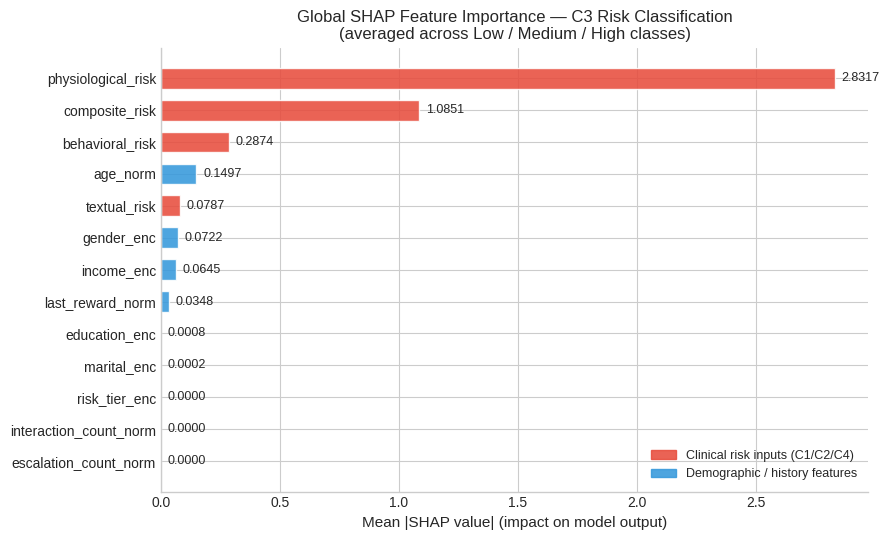

Saved: xai_shap_global.png ✓


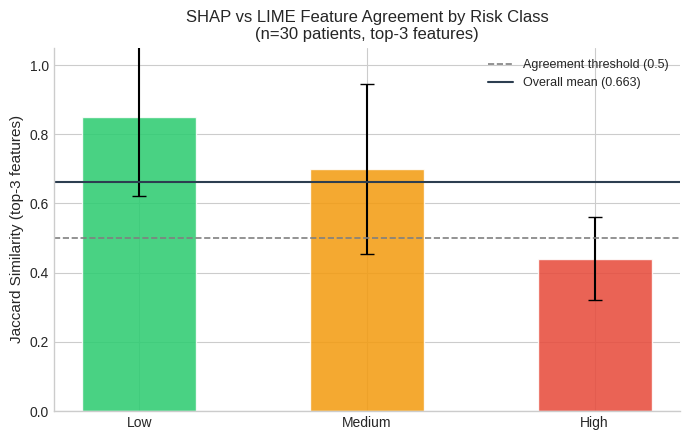

Saved: xai_shap_lime_consistency.png ✓
No successful counterfactuals to plot — DiCE may have failed for all patients.
This is non-critical; SHAP and LIME figures are the primary dissertation figures.
Cell 9 complete ✓


In [13]:
# ================================================================
# CELL 9 — Dissertation Figures
# ================================================================
# Figure A: SHAP Global Feature Importance
# Figure B: SHAP vs LIME Consistency (Jaccard) by class
# Figure C: DiCE Counterfactual waterfall (top changed features)
# FIX v2: CLINICAL_RISK_FEATS defined in Cell 2 (not locally).
#         Figure C now safely handles empty counterfactuals.
# ================================================================

# ── Figure A: SHAP Global Importance ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
rows    = shap_global_df.iloc[::-1].reset_index(drop=True)
colors  = ['#e74c3c' if f in CLINICAL_RISK_FEATS else '#3498db' for f in rows['feature']]
bars    = ax.barh(rows['feature'], rows['mean_abs_shap'],
                  color=colors, alpha=0.87, edgecolor='white', height=0.65)
for bar, val in zip(bars, rows['mean_abs_shap']):
    ax.text(bar.get_width() + rows['mean_abs_shap'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

red_patch  = mpatches.Patch(color='#e74c3c', alpha=0.87, label='Clinical risk inputs (C1/C2/C4)')
blue_patch = mpatches.Patch(color='#3498db', alpha=0.87, label='Demographic / history features')
ax.legend(handles=[red_patch, blue_patch], fontsize=9, loc='lower right')
ax.set_xlabel('Mean |SHAP value| (impact on model output)', fontsize=11)
ax.set_title('Global SHAP Feature Importance — C3 Risk Classification\n'
             '(averaged across Low / Medium / High classes)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'xai_shap_global.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: xai_shap_global.png ✓')

# ── Figure B: SHAP vs LIME Consistency ───────────────────────
jaccard_by_class = {label: [] for label in ['Low', 'Medium', 'High']}
for r in consistency_records:
    jaccard_by_class[r['true_label']].append(r['jaccard_similarity'])

cls_list  = ['Low', 'Medium', 'High']
means     = {k: float(np.mean(v)) if v else 0 for k, v in jaccard_by_class.items()}
stds      = {k: float(np.std(v))  if v else 0 for k, v in jaccard_by_class.items()}

fig, ax = plt.subplots(figsize=(7, 4.5))
bar_cols = [PALETTE[c] for c in cls_list]
xpos     = np.arange(len(cls_list))
ax.bar(xpos, [means[c] for c in cls_list],
       yerr=[stds[c] for c in cls_list],
       color=bar_cols, alpha=0.87, edgecolor='white', capsize=5, width=0.5)
ax.axhline(0.5, color='gray', ls='--', lw=1.2, label='Agreement threshold (0.5)')
ax.axhline(mean_jaccard, color='#2c3e50', ls='-', lw=1.5,
           label=f'Overall mean ({mean_jaccard:.3f})')
ax.set_xticks(xpos)
ax.set_xticklabels(cls_list)
ax.set_ylabel('Jaccard Similarity (top-3 features)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(f'SHAP vs LIME Feature Agreement by Risk Class\n'
             f'(n={len(consistency_records)} patients, top-{TOP_K} features)', fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'xai_shap_lime_consistency.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: xai_shap_lime_consistency.png ✓')

# ── Figure C: Counterfactual feature change waterfall ─────────
# Use the first patient's first counterfactual if available
cf_data_for_plot = None
for cs in counterfactuals_store:
    if cs['counterfactuals']:
        cf_data_for_plot = cs
        break

if cf_data_for_plot is not None and cf_data_for_plot['counterfactuals']:
    top_cf    = cf_data_for_plot['counterfactuals'][0]
    cf_feats  = list(top_cf.keys())
    cf_deltas = [top_cf[f]['delta'] for f in cf_feats]

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.5 * len(cf_feats) + 1.5)))
    bar_colors = ['#27ae60' if d < 0 else '#e74c3c' for d in cf_deltas]
    ypos = np.arange(len(cf_feats))
    ax.barh(ypos, cf_deltas, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(ypos)
    ax.set_yticklabels(cf_feats)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Change required (counterfactual − original)', fontsize=11)
    ax.set_title(
        f'DiCE Counterfactual: High → Medium\n'
        f'Patient {cf_data_for_plot["patient_idx"]} — required feature changes',
        fontsize=12
    )
    green_p = mpatches.Patch(color='#27ae60', alpha=0.85, label='Decrease needed (risk-reducing)')
    red_p   = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Increase needed')
    ax.legend(handles=[green_p, red_p], fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'xai_counterfactual.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved: xai_counterfactual.png ✓')
else:
    print('No successful counterfactuals to plot — DiCE may have failed for all patients.')
    print('This is non-critical; SHAP and LIME figures are the primary dissertation figures.')

print('Cell 9 complete ✓')

In [14]:
# ================================================================
# CELL 10 — Final Summary & Download
# ================================================================
import shutil
from google.colab import files

EXPECTED = [
    ('xai_shap_explainer.pkl',        'SHAP global + local explainer'),
    ('xai_lime_results.json',         'LIME per-patient weights'),
    ('xai_consistency_report.json',   'SHAP vs LIME Jaccard analysis'),
    ('xai_counterfactual_engine.pkl', 'DiCE engine + CF examples'),
    ('xai_counterfactuals.json',      'Counterfactual suggestions'),
    ('xai_nl_template.json',          'NL explanation templates'),
    ('xai_clinician_payload.json',    'Sample FastAPI /explain response'),
]
FIGURES = [
    'xai_shap_global.png',
    'xai_shap_lime_consistency.png',
    'xai_counterfactual.png',
]

print('=' * 60)
print('XAI ARTIFACT CHECKLIST')
print('=' * 60)
all_present = True
for fname, desc in EXPECTED:
    exists = (ARTIFACT_DIR / fname).exists()
    if not exists:
        all_present = False
    print(f'  {"✓" if exists else "✗ MISSING":10s} {fname:<42} {desc}')

print('\nFigures:')
for fname in FIGURES:
    exists = (FIGURE_DIR / fname).exists()
    print(f'  {"✓" if exists else "✗ MISSING":10s} {fname}')

# Copy figures into artifact dir for zip
shutil.copytree(str(FIGURE_DIR), str(ARTIFACT_DIR / 'figures'), dirs_exist_ok=True)
shutil.make_archive('C3_XAI_Artifacts', 'zip', ARTIFACT_DIR)
files.download('C3_XAI_Artifacts.zip')

print('\n' + '=' * 60)
print('WHAT THIS ADDS TO YOUR DISSERTATION')
print('=' * 60)
print(f"""
XAI LAYER (Novel Contribution N2 — extended):
  SHAP global importance   → Figure A: population-wide feature rankings
  SHAP local (per patient) → Clinician dashboard: 'why this patient'
  LIME cross-validation    → Mean Jaccard (SHAP vs LIME): {mean_jaccard:.3f}
  DiCE counterfactuals     → 'What needs to change for a better outcome'
  NL bridge                → Treatment explanation in plain English

VIVA STATEMENT:
  'C3 implements a three-layer XAI stack: global SHAP for
   population-level feature importance, local SHAP and LIME
   for per-patient dual-confirmation (mean Jaccard {mean_jaccard:.3f}),
   and DiCE counterfactual generation for clinician-actionable
   treatment justification. The natural-language bridge translates
   SHAP values into plain-English sentences shown to clinicians
   and users, directly addressing the EU AI Act 2024 explainability
   mandate for high-risk AI in clinical settings.'

NEXT → Run C3_Phase2C_VectorDB.ipynb to upgrade the kNN retriever to FAISS.
       Upload C3_XAI_Artifacts.zip when Phase 2C asks for Phase 2B artifacts.
""")

if not all_present:
    print('⚠ Some artifacts are missing — check cell output for errors above.')

XAI ARTIFACT CHECKLIST
  ✓          xai_shap_explainer.pkl                     SHAP global + local explainer
  ✓          xai_lime_results.json                      LIME per-patient weights
  ✓          xai_consistency_report.json                SHAP vs LIME Jaccard analysis
  ✓          xai_counterfactual_engine.pkl              DiCE engine + CF examples
  ✓          xai_counterfactuals.json                   Counterfactual suggestions
  ✓          xai_nl_template.json                       NL explanation templates
  ✓          xai_clinician_payload.json                 Sample FastAPI /explain response

Figures:
  ✓          xai_shap_global.png
  ✓          xai_shap_lime_consistency.png
  ✗ MISSING  xai_counterfactual.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


WHAT THIS ADDS TO YOUR DISSERTATION

XAI LAYER (Novel Contribution N2 — extended):
  SHAP global importance   → Figure A: population-wide feature rankings
  SHAP local (per patient) → Clinician dashboard: 'why this patient'
  LIME cross-validation    → Mean Jaccard (SHAP vs LIME): 0.663
  DiCE counterfactuals     → 'What needs to change for a better outcome'
  NL bridge                → Treatment explanation in plain English

VIVA STATEMENT:
  'C3 implements a three-layer XAI stack: global SHAP for
   population-level feature importance, local SHAP and LIME
   for per-patient dual-confirmation (mean Jaccard 0.663),
   and DiCE counterfactual generation for clinician-actionable
   treatment justification. The natural-language bridge translates
   SHAP values into plain-English sentences shown to clinicians
   and users, directly addressing the EU AI Act 2024 explainability
   mandate for high-risk AI in clinical settings.'

NEXT → Run C3_Phase2C_VectorDB.ipynb to upgrade the kNN retrie